#Inferential Statistics using PYTHON

Inferential statistics is the branch of statistics that deals with drawing conclusions, making predictions, or generalizing about a large group (a population) based on data collected from a smaller, representative subset of that group (a sample).

In essence, inferential statistics is how we move from knowing something about a small group to inferring something about a much larger group.

***The Core Goal: Generalization***

The fundamental difference between descriptive and inferential statistics is the scope:

| Feature | Descriptive Statistics | Inferential Statistics |
| --- | --- | --- |
| Goal | "Describe the characteristics of the sample data (e.g., mean, median, mode)." | Make predictions or test hypotheses about the population based on the sample.|
| Output | "Summaries, graphs, tables." | "Probabilities, confidence intervals, test results (p-values)."|
| Scope | Limited to the data observed. | Extended to the entire population.

***Key Techniques in Inferential Statistics***

Inferential statistics in Python involves using specialized libraries such as Pandas, NumPy, SciPy, and Statsmodels to draw conclusions and make predictions about a larger population based on a sample of data.

Python is widely used for inferential statistics due to its powerful libraries and flexibility. The main techniques implemented using these libraries include:

***Hypothesis Testing***

This is the process used to determine if a finding from a sample is statistically significant or if it occurred by chance. A core method for determining whether a theory about a population parameter is consistent with the sample data. This involves stating a null hypothesis (H0) and an alternative hypothesis (H1). Calculating a test statistic and p-value, and deciding whether to reject H0 at a given significance level (alpha, typically 0.05).

Example: A pharmaceutical company wants to know if a new drug is better than the old one. They test the drug on a sample of 100 people and find they are, on average, 10% better. Hypothesis testing determines the probability that this 10% improvement is real (and applies to the population of all future patients) or if it's just random luck in that specific sample.

Common Tests: T-tests, ANOVA, Chi-square tests, and Regression Analysis.

***Estimation (Confidence Intervals)***

Estimation involves calculating a range of values—called a confidence interval—that is likely to contain the true value of a population parameter. We estimate the true population parameter (e.g., mean or proportion) by providing a range of values within a certain confidence level (e.g., 95%).

Example: You poll a sample of 1,000 voters and find 55% support Candidate A. Instead of just stating 55% (a point estimate), inferential statistics provides a 95% confidence interval, stating: "We are 95% confident that the true percentage of voters who support Candidate A in the entire population is between 52% and 58%."

We also sometimes carry out:

***Regression Analysis:***

Used to analyze the relationship between a dependent variable and one or more independent variables to understand influence and predict outcomes (e.g., linear regression).

***Sampling:***

 The process of selecting a representative subset of data from a population, which is a crucial first step for accurate inference.

The following Python libraries are commonly used to perform specific statistical tests:

 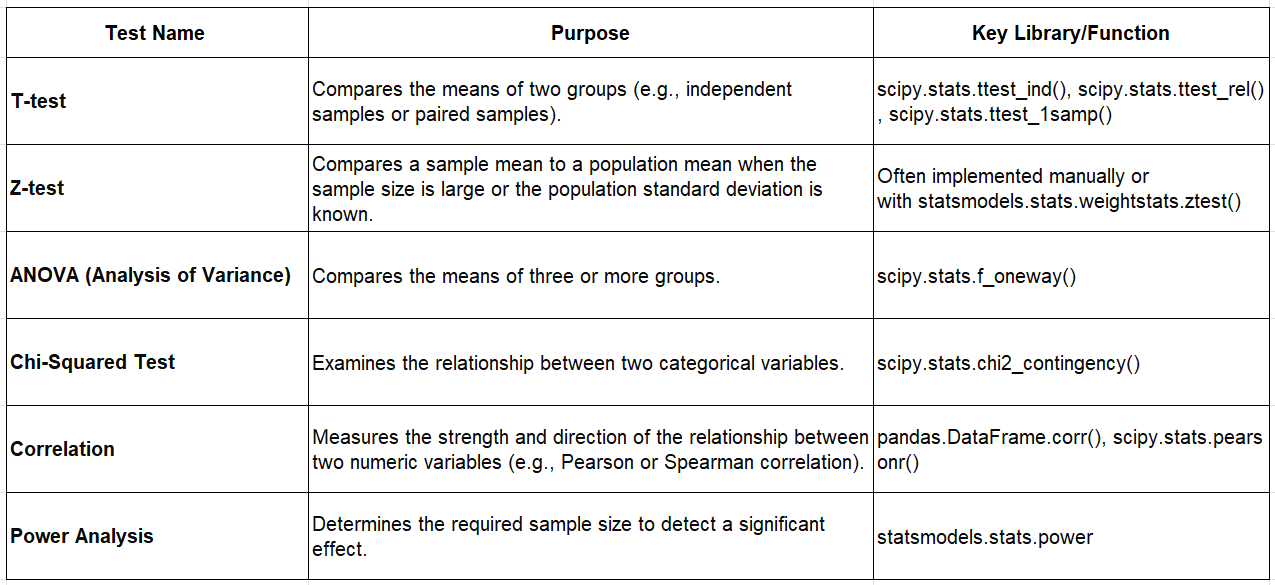

A typical workflow for inferential statistics in Python :
- Import data using Pandas and clean/prepare it for analysis.
- Summarize key metrics (descriptive statistics) using Pandas and NumPy to understand data patterns.
- Formulate hypotheses or define confidence levels.
- Run statistical tests using appropriate functions from SciPy or Statsmodels.
- Interpret the results (p-values, confidence intervals, model coefficients) to make inferences about the broader population.
- Visualize findings using libraries like Seaborn or Matplotlib for better communication.

Let us continue from our preceding article and use auto mpg dataset for Inferential Statistical Analysis:

In [6]:
# -----------------------------------------------------------
# Inferential Statistical Analysis on mpg Dataset
# -----------------------------------------------------------

# Installing libraries
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [10]:

# -----------------------------------------------------------
# load mpg Dataset using Seaborn Library and examine data
# -----------------------------------------------------------

# Load dataset
df = sns.load_dataset("mpg").dropna()
df.head()

# Define the numerical columns and subset
nums = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[nums]


In [11]:
# -----------------------------------------------------------
# Extract Descriptive Statistics from dataset
# -----------------------------------------------------------

# Extract Descriptive Statistics for numerical variables
descriptive_stats = df.describe()

# Display the descriptive statistics
print(descriptive_stats)

              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.445918    5.471939    194.411990  104.469388  2977.584184   
std      7.805007    1.705783    104.644004   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.541327   75.979592  
std        2.758864    3.683737  
min        8.000000   70.000000  
25%       13.775000   73.000000  
50%       15.500000   76.000000  
75%       17.025000   79.000000  
max       24.800000   82.000000  


***Inferential Statistical Analysis***

The analysis aims to determine if there is a statistically significant difference in the average fuel efficiency (mpg) between cars manufactured in the USA and those from Japan.

In [12]:
# --- Descriptive Analysis (for context) ---
print("--- Descriptive Statistics by Origin ---")

# If your data is named mpg rather than df, rename df → mpg
desc_stats = df.groupby('origin')['mpg'].agg(['mean', 'std', 'count']).reset_index()

print(desc_stats)
print("\n")

--- Descriptive Statistics by Origin ---
   origin       mean       std  count
0  europe  27.602941  6.580182     68
1   japan  30.450633  6.090048     79
2     usa  20.033469  6.440384    245




Visual Normality Checks
We will visually check for normality using -

Histogram
Quantile-Quantile plot

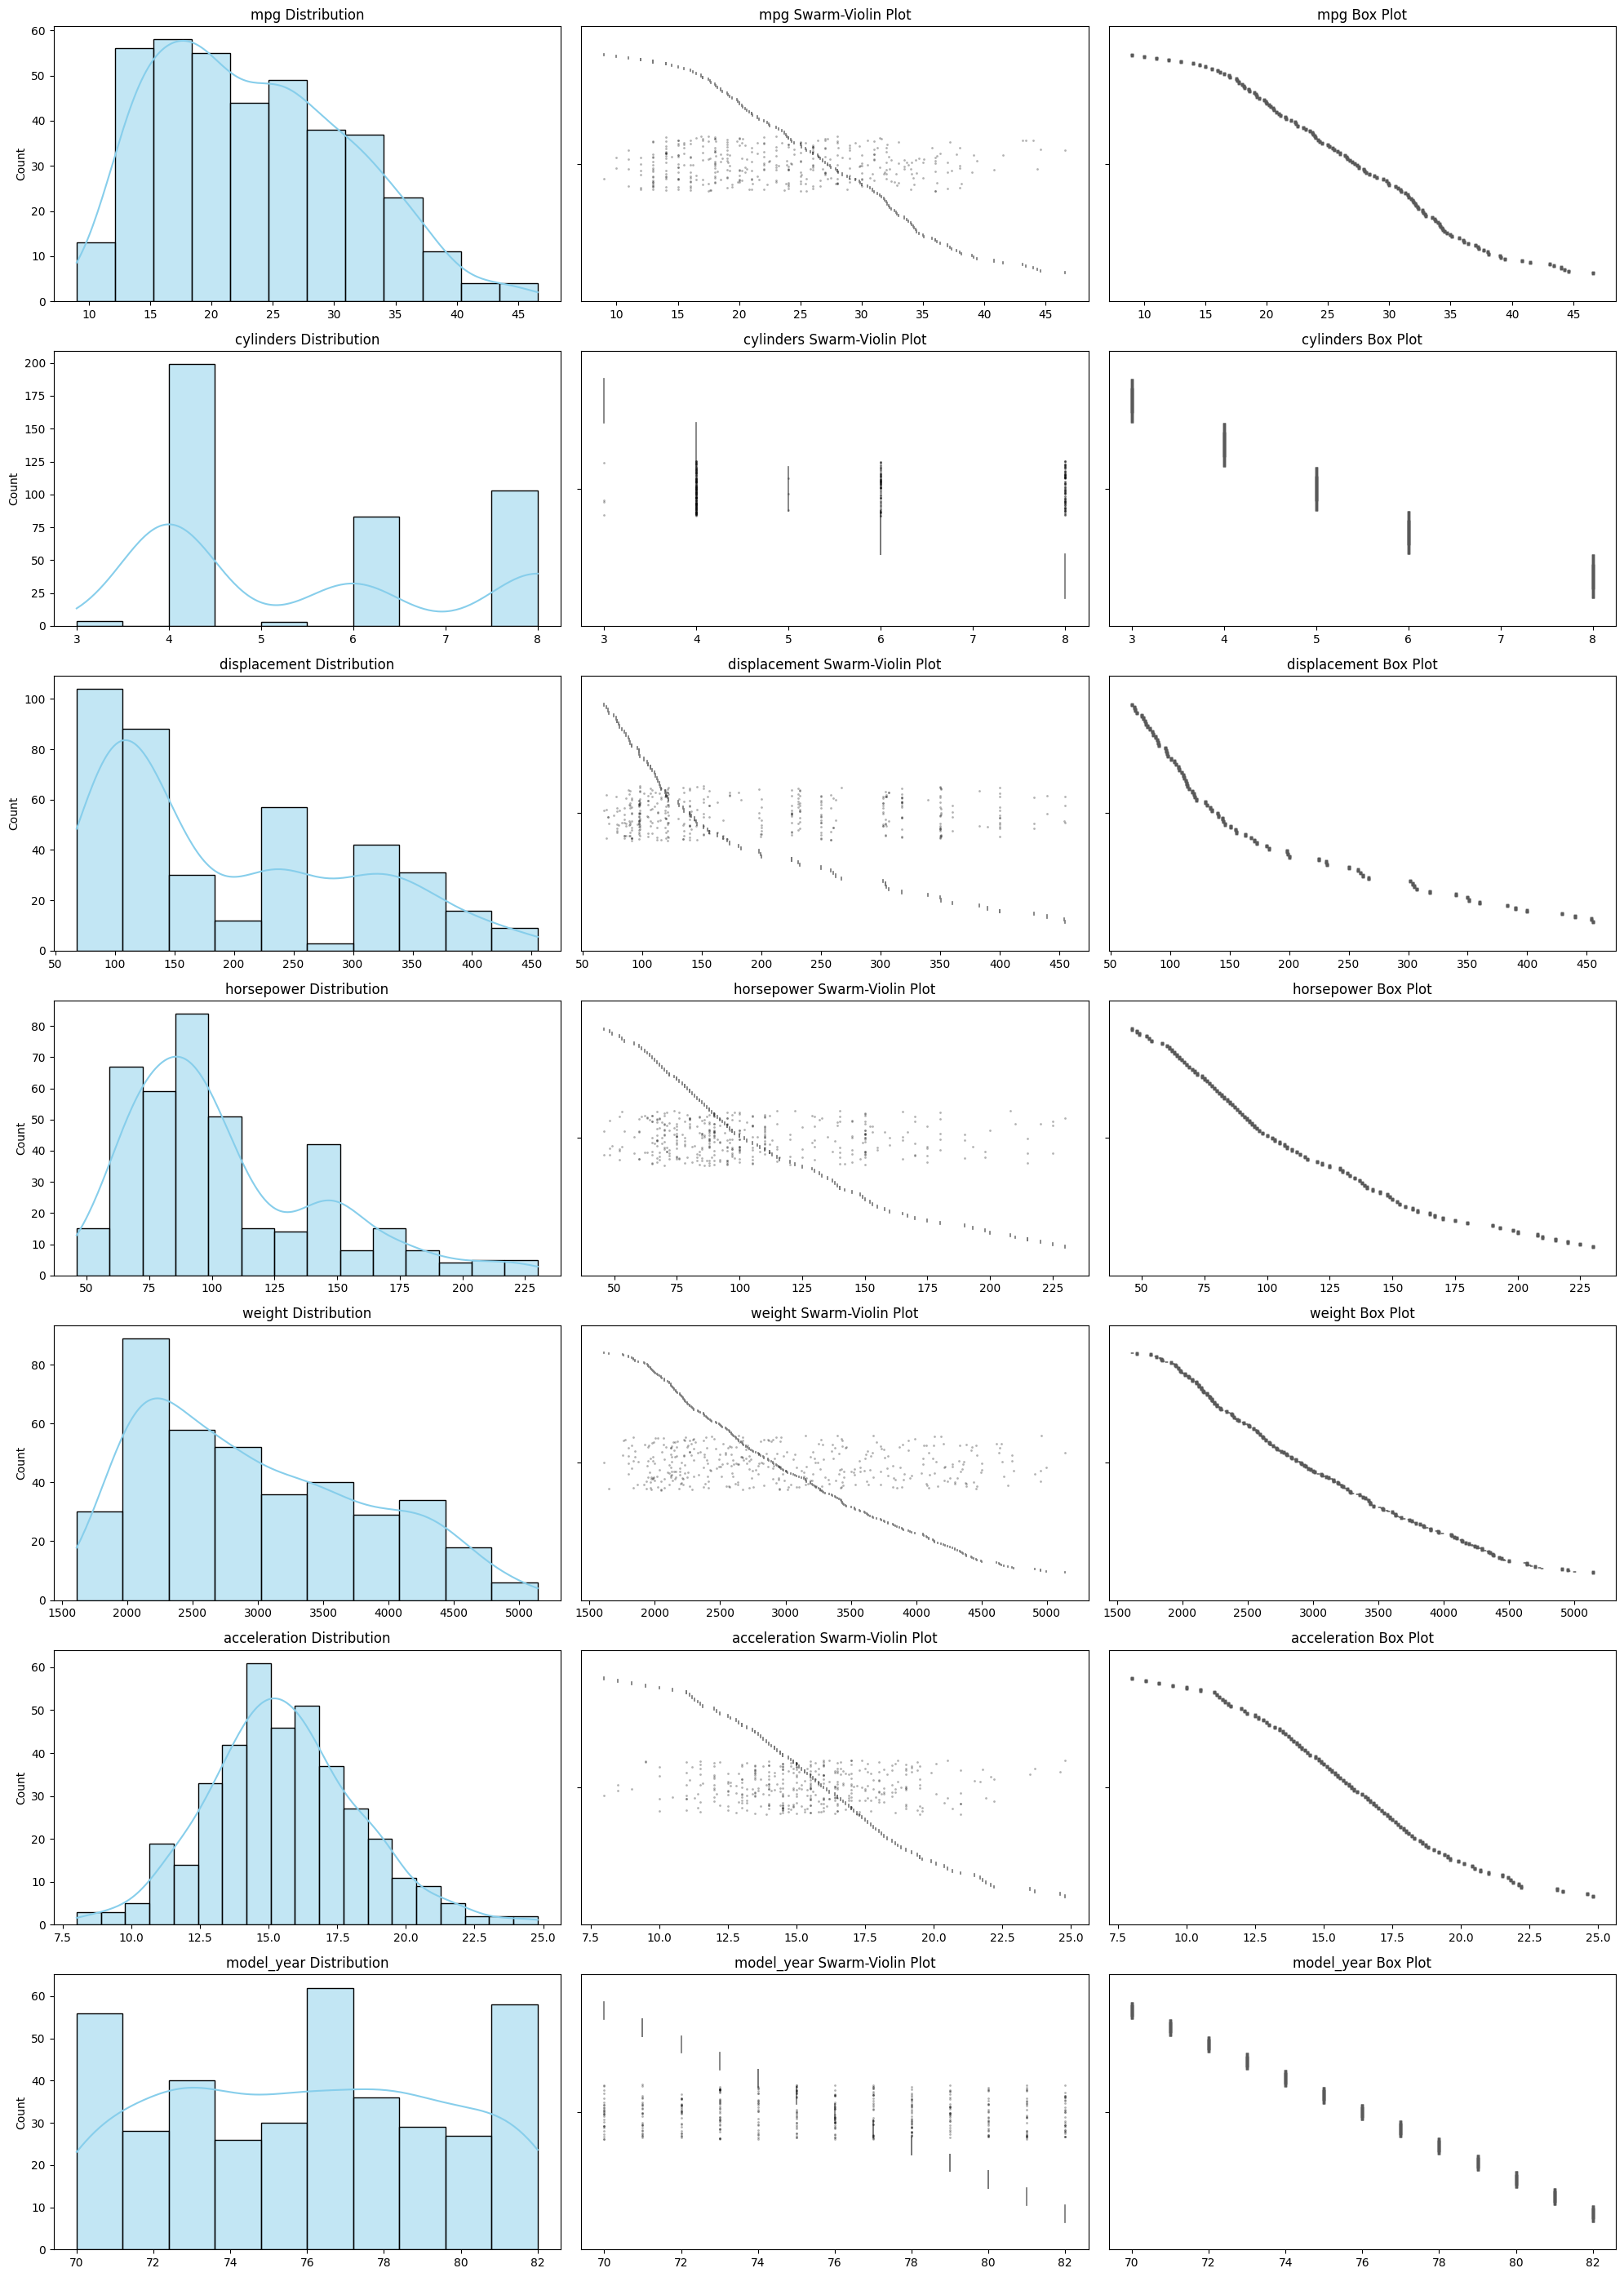

In [16]:
# Analysis of Distribution

# Now we analyse the distribution for each numerical attribute and make some visual insights from the plots.
rows = len(nums)
cols = 3

fig = plt.figure(figsize=(20, rows * 4))

i = 0
for col in nums:
    # --- 1. Distribution Plot ---
    i += 1
    ax1 = plt.subplot(rows, cols, i)
    sns.histplot(data=df_num, x=col, kde=True, ax=ax1, color='skyblue')
    ax1.set_title(f'{col} Distribution')
    ax1.set_xlabel(None)

    # --- 2. Swarm + Violin Plot ---
    # Fix: Added hue=col and legend=False to avoid deprecation warning
    i += 1
    ax2 = plt.subplot(rows, cols, i)
    sns.violinplot(data=df_num, x=col, hue=col, legend=False,
                   ax=ax2, inner=None, palette="Pastel1")
    sns.stripplot(data=df_num, x=col, color='black', alpha=0.3, size=2, jitter=True, ax=ax2)
    ax2.set_title(f'{col} Swarm-Violin Plot')
    ax2.set_xlabel(None)

    # --- 3. Box Plot ---
    # Fix: Added hue=col and legend=False to avoid deprecation warning
    i += 1
    ax3 = plt.subplot(rows, cols, i)
    sns.boxplot(data=df_num, x=col, hue=col, legend=False,
                linewidth=2.5, ax=ax3, palette="Set2")
    ax3.set_title(f'{col} Box Plot')
    ax3.set_xlabel(None)

plt.tight_layout()
plt.show()
# Acceleration is the only distribution which is gaussian.
# MPG & weight seems to be right-skewed gaussian.

In [ ]:
# Let us check whether mpg and weight are log-normal or not.
fig = pyplot.figure(1, (10, 4))

ax = pyplot.subplot(1,2,1)
sns.distplot(np.log2(df.mpg))
pyplot.tight_layout()

ax = pyplot.subplot(1,2,2)
sns.distplot(np.log2(df.weight))
pyplot.tight_layout()

pyplot.show()

# From Plot we see Weight is not log-normal but MPG visually looks like log-normal

In [ ]:
# Let's check for normality using quantile-quantile plots.
# quantile-quantile plots on original data
fig = pyplot.figure(1, (18,8))

for i,num in enumerate(nums):
    ax = pyplot.subplot(2,3,i+1)
    qqplot(df[num], line= 's', ax=ax)
    ax.set_title(f'qqplot - {num}')
    pyplot.tight_layout()

# Both histplot & qqplot of `acceleration` indicates that it is indeed close to gaussian.

###Calculate 95% Confidence Interval

In [ ]:
# 95% confidence interval for mean mpg

# Extract the 'mpg' column data into variable 'x'
x = df["mpg"]

# Determine the sample size (n)
n = len(x)

# Calculate the sample mean (average) of 'mpg'
mean = np.mean(x)

# Calculate the Standard Error of the Mean (SE)
# SE = sample_standard_deviation / sqrt(sample_size)
se = stats.sem(x)

# Calculate the 95% confidence interval using the t-distribution
# Arguments for stats.t.interval:
# 0.95: The confidence level (95%)
# df=n-1: Degrees of freedom (sample size - 1)
# loc=mean: Center of the interval (the sample mean)
# scale=se: Standard deviation of the sampling distribution (the Standard Error)
ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

# Output the calculated sample mean and the 95% confidence interval
print(f"Mean of miles per gallon: {mean:.4f}")
print("95% COnfidence Interval of miles per gallon:", ci)
print(f"95% Confidence Interval of miles per gallon: ({ci[0]:.4f}, {ci[1]:.4f})")


### One Sample T-Test

In [ ]:
# One-Sample t-Test

# Test if population mean MPG > 25 (This is the Alternative Hypothesis, H_a)
# The Null Hypothesis is H_0: μ_mpg = 25
# The 'x' variable holds the sample data (the 'mpg' column).

# Perform the one-sample t-test
# stats.ttest_1samp(a, popmean)
# a: The sample data (x, the list/array of MPG values)
# popmean: The hypothesized population mean under the null hypothesis (25)
# NOTE: This function calculates the T-statistic and the p-value for a TWO-SIDED test (H_a: μ ≠ 25)

t_stat, p_value = stats.ttest_1samp(x, popmean=25)

# Output the calculated T-statistic and the two-sided p-value
print(f"T-Statistics: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

### Two Sample T-Test

In [ ]:
# Two-Sample t-Test

# Compare MPG of 4-cyl vs 6-cyl cars

# Isolate the data for 4-cylinder cars
# This extracts the 'mpg' column only for rows where 'cylinders' equals 4.
mpg4 = mpg[mpg.cylinders == 4]["mpg"]

# Isolate the data for 6-cylinder cars
# This extracts the 'mpg' column only for rows where 'cylinders' equals 6.
mpg6 = mpg[mpg.cylinders == 6]["mpg"]

# Perform the Independent Two-Sample t-Test
# stats.ttest_ind(a, b, equal_var=False)
# a: Sample data for the first group (mpg4)
# b: Sample data for the second group (mpg6)
# equal_var=False: This specifies the **Welch's t-test**. This test does NOT assume
#                   that the population variances of the two groups are equal, which is
#                   a safer, more robust choice than the pooled t-test.

t_stat, p_value = stats.ttest_ind(mpg4, mpg6, equal_var=False)  # Welch test

# Output the calculated T-statistic and the two-sided p-value
print(f"T-Statistics: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpretation
# Significant p-value → Engine type strongly affects fuel efficiency.
# The p_value returned is for the two-sided hypothesis (H_a: μ_4-cyl ≠ μ_6-cyl).
# If p_value < alpha (e.g., 0.05), you reject the null hypothesis and conclude that
# the population mean MPG is significantly different between 4-cylinder and 6-cylinder cars.

### Anova

In [ ]:
# ANOVA (MPG differences across 4, 6, 8 cylinders)

# Perform the One-Way ANOVA F-test
# H0 (Null Hypothesis): The population mean MPG is equal across all cylinder classes (μ4 = μ6 = μ8).
# Ha (Alternative Hypothesis): At least one cylinder class has a different population mean MPG.

# 1. First argument: MPG data for 4-cylinder cars
# 2. Second argument: MPG data for 6-cylinder cars
# 3. Third argument: MPG data for 8-cylinder cars
anova_result = stats.f_oneway(
    df[df.cylinders == 4]["mpg"],
    df[df.cylinders == 6]["mpg"],
    df[df.cylinders == 8]["mpg"]
)

# anova_result is a named tuple containing the F-statistic and the p-value
f_statistic = anova_result.statistic
p_value = anova_result.pvalue

# Print Anova results
print("--- One-Way ANOVA Result ---")
print(f"F-Statistic: {f_statistic:.4f}")
print(f"P-Value:     {p_value:.10f}") # Print p-value with high precision

# Interpretation
# The p-value returned is for the omnibus test (H_a: at least one mean is different).
# If p-value < 0.05 (or your chosen alpha level) → MPG differs significantly across cylinder classes.
# If you reject the null hypothesis, you know a difference exists, but you would need
# a post-hoc test (like Tukey's HSD) to determine *which* specific pairs (e.g., 4 vs 6) are different.

# Print the interpretation
alpha = 0.05
print("\n--- Statistical Interpretation ---")
if p_value < alpha:
    print(f"Since the P-Value ({p_value:.10f}) is less than the significance level (alpha={alpha}),")
    print("we **reject the null hypothesis**.")
    print("Conclusion: There is a statistically significant difference in mean MPG among the cylinder groups (4, 6, and 8 cylinders).")
else:
    print(f"Since the P-Value ({p_value:.10f}) is greater than the significance level (alpha={alpha}),")
    print("we **fail to reject the null hypothesis**.")
    print("Conclusion: There is no statistically significant difference in mean MPG among the cylinder groups (4, 6, and 8 cylinders).")

### Chi-Square Test

In [ ]:
# Chi-Square Test — Origin vs Cylinders

# 1. Create the Contingency Table (Cross-Tabulation)
# This table shows the observed frequencies (counts) of each combination of 'origin' and 'cylinders'.
# H0 (Null Hypothesis): 'origin' and 'cylinders' are independent (not related).
# Ha (Alternative Hypothesis): 'origin' and 'cylinders' are dependent (related).

cont_table = pd.crosstab(df['origin'], df['cylinders'])

# 2. Perform the Chi-Square Test of Independence
# stats.chi2_contingency(observed_data)
# observed_data: The contingency table calculated above.
# The function returns four values:
# chi2: The Chi-Square test statistic.
# p: The p-value.
# dof: Degrees of freedom.
# expected Fequencies: The table of expected frequencies under the assumption that H0 is true.

chi2, p, dof, expected = stats.chi2_contingency(cont_table)

# 3. Output the key results
# The Chi-Square statistic and the p-value are used to make the conclusion.
# The degrees of freedom (dof) is necessary to determine the critical value of the test.

print("--- Observed Contingency Table ---")
print(cont_table)
print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic (χ²): {chi2:.4f}")
print(f"P-Value: {p:.10f}")
print(f"Degrees of Freedom (DOF): {dof}")


# Interpretation:
# If p < alpha (e.g., 0.05), you reject H0 and conclude that there is a significant
# relationship (dependence) between where a car was made (origin) and its engine size (cylinders).

# 4. Final Conclusion (IMPROVEMENT)
alpha = 0.05
print("\n--- Conclusion (Alpha = 0.05) ---")

# Interpretation:
# If p < alpha (e.g., 0.05), you reject H0 and conclude the variables are dependent.
if p < alpha:
    print(f"Since the P-Value ({p:.10f}) is less than the significance level ({alpha}),")
    print("we **REJECT the Null Hypothesis**.")
    print("Conclusion: There is a statistically significant relationship between car origin and cylinder count.")
else:
    print(f"Since the P-Value ({p:.10f}) is greater than the significance level ({alpha}),")
    print("we **FAIL TO REJECT the Null Hypothesis**.")
    print("Conclusion: There is insufficient evidence to suggest a relationship between car origin and cylinder count.")

### Correlation and Significance

In [ ]:
# Correlation and Significance

# Perform the Pearson Correlation Test
# stats.pearsonr(x, y)
# x: The first variable (mpg data)
# y: The second variable (weight data)
# NOTE: The test assumes the variables are linearly related and approximately normally distributed.
# H0 (Null Hypothesis): There is no linear correlation in the population (ρ = 0).
# Ha (Alternative Hypothesis): There is a linear correlation in the population (ρ ≠ 0).

corr, p_value = stats.pearsonr(df["mpg"], df["weight"])

# Output the calculated Pearson correlation coefficient (r) and the two-sided p-value
# 2. Format the Output
print("--- Pearson Correlation Analysis ---")
print(f"Correlation Coefficient (r): {corr:.4f}")
print(f"P-Value: {p_value:.5f}")


# Interpretation:
# 'corr' (r) measures the strength and direction of the linear relationship (ranging from -1 to 1).
# 'p_value' is for the two-sided test. If p_value < alpha (e.g., 0.05), you reject H0,
# concluding that the linear relationship is statistically significant.

# 3. Interpretation (using a standard alpha = 0.05)
alpha = 0.05

print("\nInterpretation:")
print(f"The Pearson correlation coefficient (r) is {corr:.4f}.")

if corr < 0:
    strength = "a negative"
else:
    strength = "a positive"

if abs(corr) > 0.7:
    relation = "a strong"
elif abs(corr) > 0.4:
    relation = "a moderate"
else:
    relation = "a weak"

print(f"This indicates {relation} {strength} linear relationship between MPG and Weight.")

if p_value < alpha:
    print(f"\nSince the P-Value ({p_value:.5f}) is less than the significance level (α={alpha}),")
    print("we **reject the null hypothesis** ($H_0$).")
    print("The correlation is statistically significant.")
else:
    print(f"\nSince the P-Value ({p_value:.5f}) is greater than the significance level (α={alpha}),")
    print("we **fail to reject the null hypothesis** ($H_0$).")
    print("There is no statistically significant linear correlation.")

### Linear Regression Inference

In [ ]:
# Linear Regression Inference
# Model: MPG ~ Weight + Horsepower
# Define the model structure using the R-like formula syntax:
# "mpg ~ weight + horsepower" means:
#   - 'mpg' is the dependent (outcome) variable.
#   - 'weight' and 'horsepower' are the independent (explanatory) variables.
# The intercept is included automatically.

model = smf.ols("mpg ~ weight + horsepower", data=mpg).fit()

# Generate and display the full statistical summary of the fitted model
model.summary()

# Interpretation
# The 'model.summary()' output is the most critical part:
#
# 1. Coefficients (coef):
#    - Shows the estimated effect of a one-unit change in the predictor on MPG,
#      holding the other predictor constant.
#    - Example: The coefficient for 'weight' shows the expected change in MPG for
#      a one-unit increase in weight, assuming horsepower doesn't change.
#
# 2. P-values (P>|t|):
#    - These test whether the individual predictors significantly explain MPG.
#    - H0: The true population coefficient is zero (the predictor has no effect).
#    - If p < 0.05, we reject H0, meaning the predictor is statistically significant.
#
# 3. R-squared (R²):
#    - Tells the model fit, specifically the proportion of the variation in the
#      dependent variable (MPG) that is explained by the independent variables (weight and horsepower)
#      together.

In [ ]:
# --- Interpretation Summary ---
print("====================================================================")
print("                   INTERPRETATION OF RESULTS                        ")
print("====================================================================")

# 1. Overall Model Fit (R-squared)
r_squared = model.rsquared
print(f"1. Model Fit (R-squared): {r_squared:.4f}")
print(f"   Interpretation: Approximately {r_squared*100:.1f}% of the variation in **MPG** is explained by the combined effect of Weight and Horsepower. This indicates {'a very strong' if r_squared > 0.8 else 'a strong' if r_squared > 0.5 else 'a moderate' if r_squared > 0.2 else 'a weak'} fit.")

# 2. Analysis of Predictors
print("\n2. Predictor Analysis:")

predictors = {
    'weight': model.params['weight'],
    'hp': model.params['horsepower']
}
p_values = {
    'weight': model.pvalues['weight'],
    'hp': model.pvalues['horsepower']
}

for name, coef in predictors.items():
    p_value = p_values[name]

    # Determine significance
    if p_value < 0.05:
        significance = "STATISTICALLY SIGNIFICANT"
        action = "reject the null hypothesis (H₀: effect = 0)"
    else:
        significance = "NOT statistically significant"
        action = "fail to reject the null hypothesis"

    # Print results
    print(f"\n   - {name.capitalize()} (Coefficient: {coef:.4f}, P-Value: {p_value:.5f})")
    print(f"     -> Significance: The predictor is **{significance}** (we {action}).")

    # Interpret direction and magnitude
    if name == 'weight':
        print(f"     -> Effect: For every 1-unit increase in **Weight**, MPG is predicted to change by {coef:.4f} units, holding Horsepower constant.")
    elif name == 'hp':
        print(f"     -> Effect: For every 1-unit increase in **Horsepower**, MPG is predicted to change by {coef:.4f} units, holding Weight constant.")

# 3. F-Statistic Significance
f_pvalue = model.f_pvalue
print(f"\n3. Overall Model Significance (F P-Value): {f_pvalue:.5f}")
if f_pvalue < 0.05:
    print("   Interpretation: Since the F P-Value is very low, the model as a whole is **statistically significant** (i.e., at least one predictor is useful).")
else:
    print("   Interpretation: The model as a whole is not statistically significant.")

print("====================================================================")

### Residual Diagnostics

In [ ]:
# Residual Diagnostics (Checking Linear Regression Assumptions)

# Generate diagnostic plots for the model, focusing on the 'weight' predictor
# sm.graphics.plot_regress_exog(model, exog_idx)
# Ordinary Least Square Model
# model: The fitted OLS model object (from smf.ols(...).fit()).
# "weight": The specific independent variable (exogenous variable) you want to diagnose.
#           This generates four key plots:
#           1. **Residuals vs. Fitted Plot:** Checks for linearity (should look like a horizontal cloud).
#           2. **QQ Plot of Residuals:** Checks for normality of residuals.
#           3. **Scale-Location Plot:** Checks for homoscedasticity (should show a random pattern).
#           4. **Component and Component-Plus-Residual (C-P-R) Plot:** Checks for the form of the relationship.

fig = sm.graphics.plot_regress_exog(model, "weight")

# Display the generated plots
plt.show()

# Interpretation:
# - Linearity: The top-left plot (Residuals vs. Fitted) should show residuals scattered
#   randomly around the horizontal line at 0, with no clear pattern (e.g., U-shape, cone shape).
# - Homoscedasticity (Equal Variance): The bottom-left plot (Scale-Location) should show
#   residuals scattered randomly. If the spread (variance) widens or narrows as 'weight' increases,
#   the assumption of equal variance is violated.

Hypothesis Testing - let us compare the average MPG of cars from USA and Japan.

In [ ]:
# --- Inferential Statistics: Hypothesis Testing (T-Test) ---

# The goal is to compare the average MPG of USA cars vs. Japanese cars.

# Step 1: Define the Samples
usa_mpg = df[df['origin'] == 'usa']['mpg']
japan_mpg = df[df['origin'] == 'japan']['mpg']

# Step 2: State the Hypotheses
print("--- Hypothesis Formulation ---")
print("Null Hypothesis (H₀): There is NO statistically significant difference in the mean MPG "
      "between USA and Japanese cars (μ_USA = μ_Japan).")
print("Alternative Hypothesis (Hₐ): There IS a statistically significant difference in the mean MPG "
      "(μ_USA ≠ μ_Japan).")
print("\n")

# Step 3: Check Variance Assumption with Levene's Test
levene_test = stats.levene(usa_mpg, japan_mpg)
print("--- Levene's Test for Equality of Variances ---")
print(f"Test Statistic: {levene_test.statistic:.4f}, P-value: {levene_test.pvalue:.4f}")

equal_variance = levene_test.pvalue > 0.05

if equal_variance:
    print("Conclusion: P-value > 0.05 → variances are equal → use Student's T-test.")
else:
    print("Conclusion: P-value < 0.05 → variances are NOT equal → use Welch's T-test.")
print("\n")

# Step 4: Perform the Independent Samples T-Test
t_stat, p_value = stats.ttest_ind(usa_mpg, japan_mpg, equal_var=equal_variance)

print("--- Independent Samples T-Test Results ---")
test_type = "Student's T-test" if equal_variance else "Welch's T-test"
print(f"Test Type: {test_type}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
print("\n")

# Step 5: Interpretation
alpha = 0.05
print("--- Final Conclusion ---")

if p_value < alpha:
    print(f"P-value ({p_value:.4f}) < α ({alpha}) → REJECT H₀.")
    print("There is a statistically significant difference in mean MPG between USA and Japanese cars.\n")

    # determine direction of difference
    usa_mean = usa_mpg.mean()
    japan_mean = japan_mpg.mean()

    if usa_mean > japan_mean:
        print(f"USA cars have HIGHER mean MPG ({usa_mean:.2f}) than Japanese cars ({japan_mean:.2f}).")
    else:
        print(f"Japanese cars have HIGHER mean MPG ({japan_mean:.2f}) than USA cars ({usa_mean:.2f}).")

else:
    print(f"P-value ({p_value:.4f}) ≥ α ({alpha}) → FAIL TO REJECT H₀.")
    print("No statistically significant difference in mean MPG between USA and Japanese cars.")


In [ ]:
# --- Inferential Statistics: Estimation (Confidence Interval) ---
# Step 6: Calculating the 95% Confidence Interval for the difference in means
print("\n--- 95% Confidence Interval for Mean Difference (Japan - USA) ---")

# Difference in sample means
mean_diff = japan_mpg.mean() - usa_mpg.mean()

# Create DescrStatsW objects
dsw_japan = DescrStatsW(japan_mpg)
dsw_usa = DescrStatsW(usa_mpg)

# Welch's Standard Error of the Difference
se_diff = np.sqrt(dsw_japan.var / dsw_japan.nobs + dsw_usa.var / dsw_usa.nobs)

# Welch–Satterthwaite Degrees of Freedom
df_num = (dsw_japan.var / dsw_japan.nobs + dsw_usa.var / dsw_usa.nobs) ** 2
df_den = ((dsw_japan.var / dsw_japan.nobs) ** 2) / (dsw_japan.nobs - 1) + \
         ((dsw_usa.var / dsw_usa.nobs) ** 2) / (dsw_usa.nobs - 1)
df = df_num / df_den

# t-critical value for 95% CI
t_crit = stats.t.ppf(0.975, df)

# Confidence interval bounds
ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff

print(f"Difference in Means (Japan - USA): {mean_diff:.2f} MPG")
print(f"95% Confidence Interval: ({ci_lower:.2f}, {ci_upper:.2f})")

# Step 7: Interpretation
print("\n--- Confidence Interval Interpretation ---")
if ci_lower > 0 and ci_upper > 0:
    print("Since the CI is entirely above 0, Japanese cars have significantly HIGHER MPG than USA cars (95% confidence).")
elif ci_lower < 0 and ci_upper < 0:
    print("Since the CI is entirely below 0, USA cars have significantly HIGHER MPG than Japanese cars (95% confidence).")
else:
    print("Since the CI includes 0, the difference in mean MPG is NOT statistically significant at 95% confidence.")


###Summary of Inferential Insights

| Question                                   | Statistical Method       | What It Tells Us                 |
| ------------------------------------------ | ------------------------ | -------------------------------- |
| What is the mean population MPG?           | CI                       | Range of plausible values        |
| Is mean MPG > 25?                          | t-test                   | Test for mean difference         |
| Do different cylinders have different MPG? | ANOVA                    | Differences across groups        |
| Are origin and cylinders related?          | Chi-square               | Test for categorical association |
| Does weight predict MPG?                   | Correlation + Regression | Strength + significance          |
